In [1]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import copy
import gymnasium as gym
from tqdm import tqdm
import sys
sys.path.insert(0, "../src/")
from Network import *
from inputFuc import *
from plotting import *
from utilsRL import *
from IPython.display import display, clear_output
import time
import imageio
import pickle

In [2]:
data_config = dict(default_data_config)
general_config = dict(default_general_config)
train_config = dict(default_train_config)

general_config['save_path'] = "../saved_models/Cartpole/"

#### With P learning ###
dt = general_config["dt"]
action_step = 0.02

# init both teacher and student net
batch = train_config["batch_size"]
general_config["device"] = "cuda" if torch.cuda.is_available() else "cpu"
device = general_config["device"]
print(device)

# Create the CartPole environment
env = CartPoleCustomize(obs='velocity')

n_actions = env.env.action_space.n.item()
# Get the number of state observations
obs, info = env.reset()
n_observations = obs.shape[-1]

actor_config = dict(default_model_config)
critic_config = dict(default_model_config)
actor_config['n_in'] = n_observations
critic_config['n_in'] = n_observations
actor_config['n_out'] = n_actions
critic_config['n_out'] = 1

cpu


# Train from scratch

In [17]:
def episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()
    device = actor.device

    terminated, truncated = False, False
    total_reward=0
    lamd = 0.9
    gamma = 0.99 # are they different?
    rwd_scale = 0.2

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)
    observations = observations.to(device)
    delta_rec = 0

    with torch.no_grad():
        t = 0
        while not terminated and not truncated:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            reward *= rwd_scale

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]
            for k in range(1, interpolate):
                value_next,_ = critic_target.step(observations[k])

            delta = reward + gamma*value_next - value
            delta_rec += torch.abs(delta)           
            delta = torch.clamp(delta, -0.015, 0.015).to(device)
            actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions).to(device)-p)
            actor.backwardsRL(delta.item(), lamd)            
            critic.prop(1.)
            critic.backwardsRL(delta.item(), lamd)

            observation = observation_next
            total_reward+=reward
            t += 1

        torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
        torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
        optimizer_actor.step()
        optimizer_critic.step()
        optimizer_actor.zero_grad(set_to_none=False)
        optimizer_critic.zero_grad(set_to_none=False)
        soft_update(critic_target, critic, tau = 0.05)      

    return total_reward/rwd_scale, t, delta_rec/t

In [18]:
#Change schedular, add temporatue?
actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)
for p in critic_target.parameters():
    p.requires_grad = False
hard_update(critic_target, critic)
num_episode = 4000

optimizer_actor = torch.optim.Adam(
    actor.parameters(),
    lr=1e-4, betas=(0.9, 0.999)
)

optimizer_critic = torch.optim.Adam(
    critic.parameters(),
    lr=2e-3, betas=(0.9, 0.999)
)

In [19]:
save_dict = {'step':[], 'reward':[]}
R_avg, duration_avg, delta_avg = 10, 0, 0
best_R, best_duration = 0, 0
R_rec, delta_rec = [], []
for i in range(num_episode):
    total_reward, duration, delta = episode_interpolate(env, actor, critic, critic_target, optimizer_actor, optimizer_critic)
    save_dict['step'].append(duration)
    save_dict['reward'].append(total_reward)
    if total_reward < R_avg:
        actor.beta *= 0.997
        critic.beta *= 0.997
    else:
        actor.beta += 0.001
        critic.beta += 0.001
    R_avg = 0.98*R_avg + 0.02*total_reward
    duration_avg = 0.98*duration_avg + 0.02*duration
    delta_avg = 0.98*delta_avg + 0.02*delta
    if i%100==99:
        R_rec.append(R_avg)
        saved = False
        if R_avg > best_R:
            best_R = R_avg
        print(f"Reward:{R_avg:.2f}, Steps:{duration_avg:.2f}, delta:{delta_avg.item():.3f}, beta:{actor.beta:.3f}")
    if duration_avg > 495:
        print("Learning Success")
        break
best_actor_state = actor.state_dict().copy()
best_critic_state = critic.state_dict().copy()      
env.close() # Close the environment
save_dict['step'] = np.array(save_dict['step'])
save_dict['reward'] = np.array(save_dict['reward'])

Reward:23.12, Steps:27.05, delta:0.092, beta:0.966
Reward:49.41, Steps:59.82, delta:0.109, beta:0.931
Reward:75.03, Steps:91.36, delta:0.105, beta:0.868
Reward:99.40, Steps:116.41, delta:0.101, beta:0.813
Reward:146.22, Steps:168.11, delta:0.086, beta:0.774
Reward:168.26, Steps:194.47, delta:0.083, beta:0.698
Reward:198.75, Steps:224.87, delta:0.080, beta:0.645
Reward:217.75, Steps:245.05, delta:0.075, beta:0.595
Reward:275.48, Steps:306.35, delta:0.074, beta:0.595
Reward:331.44, Steps:365.64, delta:0.073, beta:0.589
Reward:380.54, Steps:414.90, delta:0.082, beta:0.587
Reward:429.15, Steps:456.07, delta:0.069, beta:0.612
Reward:461.93, Steps:479.51, delta:0.057, beta:0.649
Reward:477.88, Steps:491.79, delta:0.054, beta:0.700
Learning Success


### Saving

In [6]:
torch.save(best_actor_state, general_config['save_path']+"actor%d.ckp"%int(best_R))
torch.save(best_critic_state, general_config['save_path']+"critic%d.ckp"%int(best_R))

In [20]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)

All_record.append(save_dict)

with open(save_path, 'wb') as handle:
    pickle.dump(All_record, handle, protocol=pickle.HIGHEST_PROTOCOL)

### Make figure

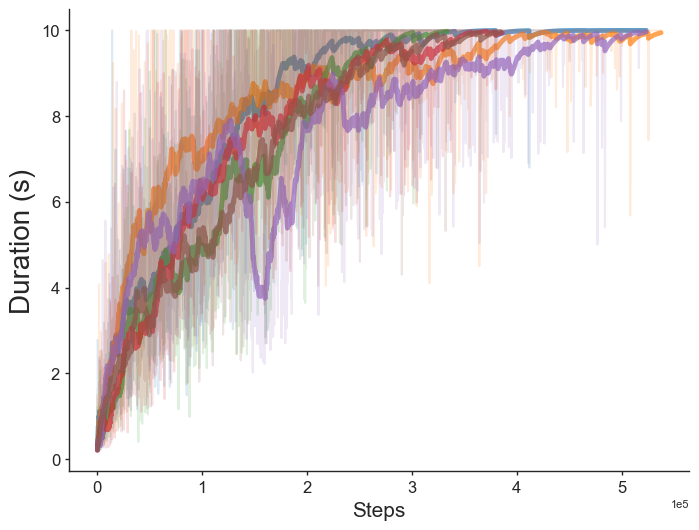

In [49]:
save_path = "../Figures/CartpoleTrainRecord.pkl"
with open(save_path, 'rb') as handle:
    All_record = pickle.load(handle)
color=[
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', 
    '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
    '#bcbd22', '#17becf'
]

fig, ax = plt.subplots(figsize = (8, 6))
for j, one_train in enumerate(All_record):
    #plt.plot()
    step = one_train['step']
    cum_step = np.cumsum(step)
    smoothed = []
    t_lp = 10#step[0]
    for i, t in enumerate(step):
        t_lp = 0.95*t_lp + 0.05*t
        smoothed.append(t_lp)
    smoothed = np.array(smoothed)*action_step
    ax.plot(cum_step, step*action_step, alpha = 0.15, color=color[j])
    ax.plot(cum_step, smoothed, color=color[j], linewidth=3.5, alpha=0.7)
ax.set_xlabel("Steps", fontsize=15)
#ax.set_xticks([1e4, 2e4], [])
ax.set_ylabel("Duration (s)", fontsize=20)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(axis='both', which='major', labelsize=12)
ax.ticklabel_format(style='sci', axis='x', scilimits=(0,0))

plt.savefig('../Figures/CartpoleDuration.png')
plt.show()

# Adaptation and visulize

In [50]:
def episode_interpolate_adapt(env, actor, critic, critic_target, 
                              optimizer_actor, optimizer_critic,
                              adapt=False, visualize=False,):
    # Run one episode
    observation, _ = env.reset()
    actor.reset()
    critic.reset()
    critic_target.reset()

    terminated, truncated = False, False
    total_reward=0
    gamma=0.9

    interpolate = 2
    interp_k = torch.linspace(0, 1, interpolate)
    observations = observation[None,:, :].repeat(interpolate, 1, 1)

    action_step = 20 #ms
    if visualize:
        plt.figure(figsize=(5,4))
    frames = []

    with torch.no_grad():
        t = 0
        while not terminated and t<1000:
            # Take a random action
            for k in range(1, interpolate):
                u, _ = actor.step(observations[k])
                if adapt:
                    value,_ = critic.step(observations[k])

            p = torch.softmax(u, dim=1)
            action = np.random.choice(n_actions, p=p[0].cpu().numpy())

            # Step the environment
            observation_next, reward, terminated, truncated,_ = env.step(action)
            frame = env.render()
            frames.append(frame)
            if visualize:
                plt.imshow(frame)
                plt.axis("off")
                display(plt.gcf())
                clear_output(wait=True)

            observations = observation[None, :, :] + interp_k[:, None, None] * (observation_next - observation)[None, :,  :]

            if adapt:
                for k in range(1, interpolate):
                    value_next,_ = critic_target.step(observations[k])
    
                delta = reward + gamma*value_next - value
                delta = torch.clamp(delta, -0.015, 0.015)
                actor.prop(F.one_hot(torch.tensor(action), num_classes=n_actions)-p)
                actor.backwardsRL(delta.item(), gamma)
                critic.prop(1.)
                critic.backwardsRL(delta.item(), gamma)

            observation = observation_next
            total_reward+=reward

            t+=1
            if t%20==0 and adapt:
                torch.nn.utils.clip_grad_norm_(actor.parameters(), 1.0)
                torch.nn.utils.clip_grad_norm_(critic.parameters(), 1.0)
                optimizer_actor.step()
                optimizer_critic.step()
                optimizer_actor.zero_grad(set_to_none=False)
                optimizer_critic.zero_grad(set_to_none=False)
                soft_update(critic_target, critic, tau = 0.05) 

    return total_reward, frames

In [58]:
num_trials = 100
wind = 4.

visualize = True if num_trials<=2 else False
env = WindCartPoleEnv(wind=wind, render_mode="rgb_array")
env = CartPoleCustomize(env=env)  #Do we need time limit?
#env = CartPoleCustomize(env=None, display = True)
actor_state_dict = torch.load(general_config['save_path']+"actor486.ckp", weights_only=False)
critic_state_dict = torch.load(general_config['save_path']+"critic486.ckp", weights_only=False)

actor = buildRLNet(actor_config, general_config).to(device)
critic = buildRLNet(critic_config, general_config).to(device)
critic_target = buildRLNet(critic_config, general_config).to(device)

In [59]:
#Without online adpation
noAdapt_reward = []
# actor.load_state_dict(actor_state_dict)
# critic.load_state_dict(critic_state_dict)
# critic_target.load_state_dict(critic_state_dict)
actor.load_state_dict(best_actor_state)
critic.load_state_dict(best_critic_state)
critic_target.load_state_dict(best_critic_state)

for i in range(num_trials):
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=False, visualize=visualize,)
    noAdapt_reward.append(total_reward)
    if total_reward < 0:
        imageio.mimsave("../Figures/cartpole_noAdapt%.1f.gif"%total_reward, frames, fps=30)

noAdapt_reward = np.array(noAdapt_reward)
print("Average Reward without adaptation: ", noAdapt_reward.mean())

Average Reward without adaptation:  236.00581


In [84]:
#With online adpation
Adapt_reward = []
for i in range(num_trials):
    actor.load_state_dict(actor_state_dict)
    critic.load_state_dict(critic_state_dict)
    critic_target.load_state_dict(critic_state_dict)
    
    # optimizer_actor = torch.optim.Adam(
    #     actor.parameters(),
    #     lr=1e-4,
    #     betas=(0.9, 0.999)
    # )
    
    # optimizer_critic = torch.optim.Adam(
    #     critic.parameters(),
    #     lr=1e-3,
    #     betas=(0.9, 0.999)
    # )

    optimizer_actor = torch.optim.RMSprop(
        actor.parameters(),
        lr=1e-4, alpha=0.8
    )
    
    optimizer_critic = torch.optim.RMSprop(
        critic.parameters(),
        lr=1e-3, alpha=0.8
    )
    
    total_reward, frames = episode_interpolate_adapt(env, actor, critic, critic_target,
                                                     optimizer_actor, optimizer_critic,
                                                     adapt=True, visualize=visualize,)
    Adapt_reward.append(total_reward)
    if total_reward > 800:
        imageio.mimsave("../Figures/cartpole_Adapt%.1f.gif"%total_reward, frames, fps=30)
Adapt_reward = np.array(Adapt_reward)
print("Average Reward with adaptation: ", Adapt_reward.mean())

Average Reward with adaptation:  322.57947


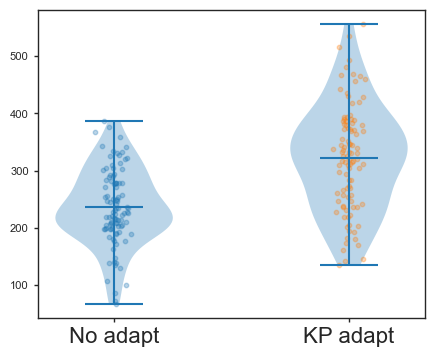

In [86]:
#TODO plot the bar with many runs
fig, ax = plt.subplots(figsize = (5, 4))

data = [noAdapt_reward, Adapt_reward]
ax.violinplot(data, positions=[0,1], showmeans=True)
ax.set_xticks([0,1], ['No adapt', 'KP adapt'], fontsize=16)

for i, d in enumerate(data):
    x = np.random.normal(i, 0.03, size=len(d))  # small horizontal jitter
    ax.scatter(x, d, alpha=0.3, s=10)

#plt.savefig('../Figures/CartpoleAdpation.png')
plt.show()

In [ ]:
#TODO multi-episode learn, faster than BPTT?